# Overview

This Jupyer Notebook will run several types of ML algorithms on the credit card dataset, which includes Logistic Regression, Decision Tree and some ensemble methods such as Random Forest. THE ROC AUC score will be used as a way to validate the models. Accuracy/Precision will also be used. Feature selection methods such as F-tests and correlation matrices will be used at the start to try to figure out what makes the most sense.

In large part this project is similar to what ***Data Science Projects with Python*** does throughout the text but with some differences. Part of this is because some features have been deprecated since, and part of this is because there were some extra models that could be ran. For example, Linear Regression was not ran through regularization and interaction features so I'll do that here. The point is to create a wide variety of models, and time them to figure out which methods make the most sense. There may be a really good model but if it takes hours to run, it may not be worth it compares to one that gives good enough results in a handful of minutes.

Additionally, prior to running the models, the data needs to be cleaned and explored, which will broadly follow the book's treatment. This also includes feature selection and exploration such as F-tests and correlation matrices. Similar to the textbook this is derived from, the features will be a subset of the total which excludes gender for ethical reasons (a reasonable exclusion).

## Logistic Regression
Logistic Regression will be done using Cross Validation, Engineered Features, and Regularization (L1, L2 and "L1.5", which is using an l1_ratio of 0.5). The base case, Logistic Regression without any bells or whistles, will be done solely to compare 

## Decision Tree and Random Forest
Decision Trees and Ramdom Forests will have some tuning of maximum depth and number of trees when it comes to the random forest.

## XGBoost
XGBoost will be applied to a random forest, with some optimizing of the maximum leaves. SHAP will be used to validate the results.

In [3]:
import warnings
warnings.filterwarnings("ignore")

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
df = pd.read_excel('default_of_credit_card_clients__courseware_version_1_21_19.xls')

In [5]:
df.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_1',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default payment next month'],
      dtype='object')

In [6]:
df['ID'].nunique()

29687

In [7]:
id_counts = df['ID'].value_counts()
id_counts.value_counts()

count
1    29374
2      313
Name: count, dtype: int64

### Duplicate Data
There are 313 IDs which are duplicate so those need to be removed, which will be done using a Boolean Mask.

The *dupe_mask* lists all duplicate IDs, the *df_zero_mask* creates a bollean matrix to showwhere data is 0, the *feature_zero_mask* Series which identifies where the data is all zeroes, which also needs to be removed. The Dataframe *df_clean_1* will remove all zeroes, and hopefully duplicates.

In [8]:
dupe_mask = id_counts == 2
df_zero_mask = df == 0
feature_zero_mask = df_zero_mask.iloc[:,1:].all(axis=1)
df_clean_1 = df.loc[~feature_zero_mask,:].copy()
df_clean_1['ID'].nunique(), df_clean_1.shape

(29685, (29685, 25))

In [9]:
df_clean_1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29685 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   ID                          29685 non-null  object
 1   LIMIT_BAL                   29685 non-null  int64 
 2   SEX                         29685 non-null  int64 
 3   EDUCATION                   29685 non-null  int64 
 4   MARRIAGE                    29685 non-null  int64 
 5   AGE                         29685 non-null  int64 
 6   PAY_1                       29685 non-null  object
 7   PAY_2                       29685 non-null  int64 
 8   PAY_3                       29685 non-null  int64 
 9   PAY_4                       29685 non-null  int64 
 10  PAY_5                       29685 non-null  int64 
 11  PAY_6                       29685 non-null  int64 
 12  BILL_AMT1                   29685 non-null  int64 
 13  BILL_AMT2                   29685 non-null  int64 


### PAY_1
PAY_1 is an object rather than an int64 like it should be, according to the data document anyway since it would take on values: -1, and 1-7.

In [10]:
valid_pay_1_mask = df_clean_1['PAY_1'] != 'Not available'
df_clean_2 = df_clean_1.loc[valid_pay_1_mask,:].copy()
df_clean_2.shape

(26664, 25)

In [11]:
df_clean_2['PAY_1'] = df_clean_2['PAY_1'].astype('int64')
df_clean_2[['PAY_1', 'PAY_2']].info()

<class 'pandas.core.frame.DataFrame'>
Index: 26664 entries, 0 to 29999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   PAY_1   26664 non-null  int64
 1   PAY_2   26664 non-null  int64
dtypes: int64(2)
memory usage: 624.9 KB


### Value Merge
After looking at the Education data, it may be a good idea to just merge 0, 5, and 6 into 4 (which represents others) since they're all fairly small categories (totaling less than 300) and undocumented on the data document.

Similar things can be done for Marriage.

In [12]:
df_clean_2['EDUCATION'].value_counts()

EDUCATION
2    12458
1     9412
3     4380
5      245
4      115
6       43
0       11
Name: count, dtype: int64

In [13]:
df_clean_2['EDUCATION'].replace(to_replace=[0, 5, 6], value=4, inplace=True)
df_clean_2['EDUCATION'].value_counts()

EDUCATION
2    12458
1     9412
3     4380
4      414
Name: count, dtype: int64

In [14]:
df_clean_2['MARRIAGE'].value_counts()

MARRIAGE
2    14158
1    12172
3      286
0       48
Name: count, dtype: int64

In [15]:
df_clean_2['MARRIAGE'].replace(to_replace=0, value=3, inplace=True)
df_clean_2['MARRIAGE'].value_counts()

MARRIAGE
2    14158
1    12172
3      334
Name: count, dtype: int64

### One Hot Encoding
Education will be one hot encoding to help in analysis by ML alogorithms. First, an empty dataframe will be created, and then the number based Education category will be mapped onto strings representing each education category, and then create four columns (one for each remaining education category), where each row will have only a single one in one of the four columns, and a zero in the other three.

In [16]:
df_clean_2['EDUCATION_CAT'] = 'none'
cat_mapping = {1: "graduate school", 2: "university", 3: "high school", 4: "others"}
df_clean_2['EDUCATION_CAT'] = df_clean_2['EDUCATION'].map(cat_mapping)
edu_ohe =pd.get_dummies(df_clean_2['EDUCATION_CAT'])
df_with_ohe = pd.concat([df_clean_2, edu_ohe], axis=1) 
df_with_ohe[['EDUCATION_CAT', 'graduate school', 'high school', 'university','others']].head(10)

,EDUCATION_CAT,graduate school,high school,university,others
0,university,False,False,True,False
1,university,False,False,True,False
2,university,False,False,True,False
3,university,False,False,True,False
4,university,False,False,True,False
5,graduate school,True,False,False,False
6,graduate school,True,False,False,False
7,university,False,False,True,False
8,high school,False,True,False,False
9,high school,False,True,False,False


## Set up for ML Models

This section creates the dataframe made up of the cleaned data, and then removes the same features the textbook removed.

In [17]:
df = pd.read_csv('Chapter_1_cleaned_data.csv')
features_response = df.columns.tolist()
items_to_remove = ['ID', 'SEX', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'EDUCATION_CAT', 'graduate school', 'high school', 'none', 'others', 'university']
features_response = [item for item in features_response if item not in items_to_remove]
df = df[features_response]
X = df[features_response[:-1]].values
y=df['default payment next month'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=24)


### F-Tests and Univariate Feature Selection
This section will look at what features are the most likely to be useful in the upcoming ML alogorithms.

In [18]:
from sklearn.feature_selection import f_classif
[f_stat, f_p_value] = f_classif(X,y)
f_test_df=pd.DataFrame({'Feature':features_response[:-1], 'F statistic':f_stat, 'p value':f_p_value})
f_test_df.sort_values('p value')
f_test_df.head()

,Feature,F statistic,p value
0,LIMIT_BAL,651.324071,5.838366e-142
1,EDUCATION,32.637768,1.122175e-08
2,MARRIAGE,18.078027,2.127555e-05
3,AGE,5.479140,1.925206e-02
4,PAY_1,3156.672300,0.000000e+00


A customer's credit limit is the best predictor of whether or not they will default on payment next month, which makes quite a bit of sense, and because of that it may be nice to see the normalized distributions of credit limits versus if they defaulted or not.

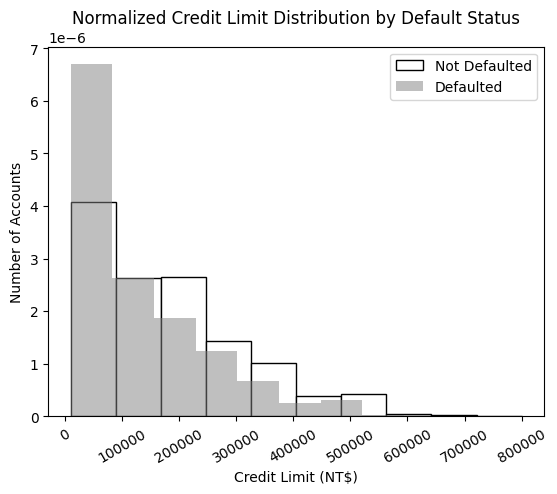

In [42]:
pos_bool_mask = y == 1
neg_bool_mask = y == 0

axes=plt.axes()
axes.set_xlabel("Credit Limit (NT$)")
axes.set_ylabel("Number of Accounts")
axes.set_title("Normalized Credit Limit Distribution by Default Status")
axes.hist(df.loc[neg_bool_mask, 'LIMIT_BAL'], edgecolor='black', color='white', density=True)
axes.hist(df.loc[pos_bool_mask, 'LIMIT_BAL'], alpha=0.5, edgecolor=None, color='grey', density=True)
axes.legend(['Not Defaulted', 'Defaulted'])
axes.tick_params(axis='x', labelrotation=30)

## Logistic Regression
This section will use GridSearchCV to look over a wide range of C values, and L1 Rations to find the best model after applying Polynomial Features to create new interaction features, and scaling the values to keep everything within the same order of magnitude.

In [85]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import PolynomialFeatures
min_max_sc = MinMaxScaler()
make_interactions = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)

In [86]:
cValExponents = np.linspace(2, -3, 6)
C_vals = np.array(float(10) ** cValExponents)
params={'C':C_vals, 'l1_ratio':[0,0.5,1]}
LogReg=  LogisticRegression(solver='saga', random_state=42, max_iter=1000)
Grid =  GridSearchCV(LogReg, params, return_train_score=True)
scaler_CV_pipeline = Pipeline(steps=[('make_features', make_interactions), ('scaler',min_max_sc),('model', Grid)])
scaler_CV_pipeline.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('make_features', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",2
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",True
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",False
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False


In [87]:
y_train_predict_proba_GSCV=scaler_CV_pipeline.predict_proba(X_train)
roc_auc_score(y_train, y_train_predict_proba_GSCV[:,1])

0.7353671945534858

In [88]:
LogReg.fit(X_train, y_train)
y_train_predict_proba_LG=scaler_CV_pipeline.predict_proba(X_train)
roc_auc_score(y_train, y_train_predict_proba_LG[:,1])

0.7353671945534858

### Result

0.75 is a pretty good result for logsitic regression though at 12 minutes, it does take a long time, and isn't a massive increase over the basic Logistic Regression model. Likely the C values and l1 ratios were simply not the correct values to test. It's possible a much larger or smaller C value was more optimal. Regardless, every bit of improvement is good.

## Decision Tree

GridSearchCV will be used to fit a decision tree and random forest ensemble after poking around to see which features seem to be the most relevant using graphviz.

In [89]:
from sklearn import tree
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
import graphviz
dt = tree.DecisionTreeClassifier(max_depth=3)
dt.fit(X_train, y_train)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

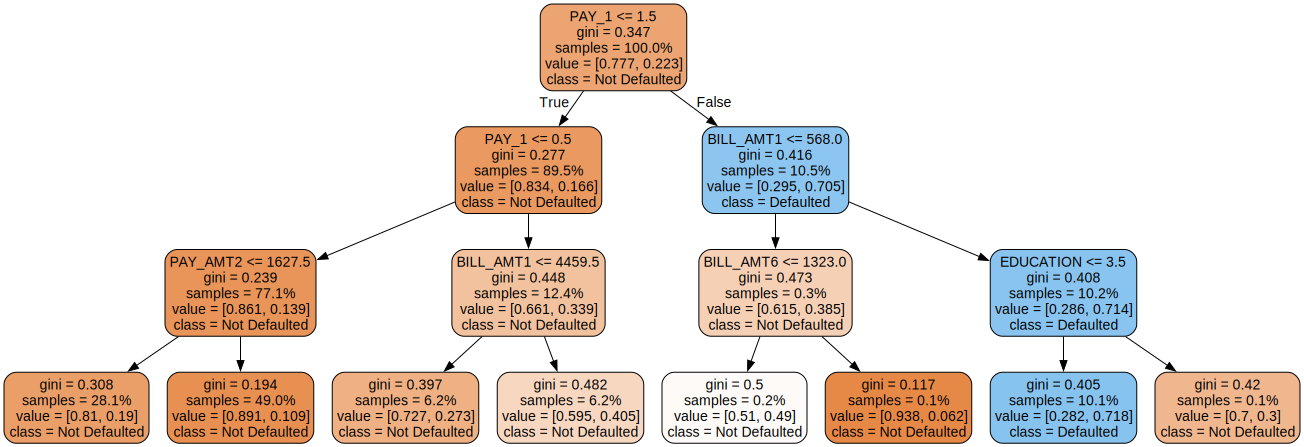

In [90]:
dot_data = tree.export_graphviz(dt, out_file=None, filled=True, rounded=True, feature_names=features_response[:-1],proportion=True, class_names=['Not Defaulted', 'Defaulted'])
graph = graphviz.Source(dot_data)
graph

In [91]:
params = {'max_depth':[1, 2, 4, 6, 8, 10, 12]}
dt=tree.DecisionTreeClassifier()
dt_cv = GridSearchCV(dt, param_grid=params, scoring='roc_auc', n_jobs=None, refit=True, cv=4, verbose=1, pre_dispatch=0,error_score=np.nan,return_train_score=True)
dt_cv.fit(X_train, y_train)
y_train_predict_proba_dt=dt_cv.predict_proba(X_train)
roc_auc_score(y_train, y_train_predict_proba_dt[:,1])

Fitting 4 folds for each of 7 candidates, totalling 28 fits


0.7723109349780848

In [92]:
params = {'max_depth':[1, 2, 4, 6, 8, 10, 12], 'gamma':np.linspace(0,3,10)}

rf = RandomForestClassifier(n_estimators=10, criterion='gini',max_depth=3,min_samples_split=2, min_samples_leaf=1,min_weight_fraction_leaf=0.0, max_features=3, max_leaf_nodes=None,
    min_impurity_decrease=0.0, bootstrap=True, oob_score=False, n_jobs=None, random_state=42, verbose=0, warm_start=False, class_weight=None)
rf_params ={'n_estimators':list(range(10,110,10))}
rf_cv=GridSearchCV(rf, param_grid=rf_params, scoring='roc_auc', n_jobs=None, refit=True, cv=4, verbose=1,error_score='raise',return_train_score=True)
rf_cv.fit(X_train, y_train)
y_train_predict_proba_rf=rf_cv.predict_proba(X_train)
roc_auc_score(y_train, y_train_predict_proba_rf[:,1])

Fitting 4 folds for each of 10 candidates, totalling 40 fits


0.767621210560455

## Conclusion

In this case, random forest and decision tree both did better in less time than logistic regression which makes sense as the problem seems to fit those models more as it is more or less a binary classification problem. 

The Random Forest did do worse than the decision tree which may just be a poor choice of param grid or just bad luck.

It was also likely more efficient to not use the polynomial features, as seen below. The Polynomial Features contribute a lot to a better score, at the cost of exponentially longer training times. As can also be seen, expanding the C range does not do much for the ROC AUC.

In [93]:
params={'C':C_vals, 'l1_ratio':[0,0.5,1]}
LogReg=  LogisticRegression(solver='saga', random_state=42, max_iter=1000)
Grid =  GridSearchCV(LogReg, params, return_train_score=True)
Grid.fit(X_train, y_train)
y_train_predict_proba_Grid=Grid.predict_proba(X_train)
roc_auc_score(y_train, y_train_predict_proba_Grid[:,1])

0.6508994327959317

In [94]:
scaler_pipeline = Pipeline(steps=[('scaler',min_max_sc),('model', Grid)])
scaler_pipeline.fit(X_train, y_train)
y_train_predict_proba_scale=scaler_pipeline.predict_proba(X_train)
roc_auc_score(y_train, y_train_predict_proba_scale[:,1])

0.7181527744958458

In [95]:
newCValExponents = np.linspace(5, -5, 11)
new_C_vals = np.array(float(10) ** newCValExponents)
new_params = {'C':new_C_vals, 'l1_ratio':[0,0.5,1]}
new_Grid =  GridSearchCV(LogReg, new_params, return_train_score=True)
new_scaler_pipeline = Pipeline(steps=[('scaler',min_max_sc),('model', new_Grid)])
new_scaler_pipeline.fit(X_train, y_train)
y_train_predict_proba_NS=new_scaler_pipeline.predict_proba(X_train)
roc_auc_score(y_train, y_train_predict_proba_NS[:,1])

0.7181527744958458